Sử dụng dữ liệu creditcardfraud ( tìm hiểu lí do chọn bộ dữ liệu này)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Đọc dữ liệu trực tiếp
df = pd.read_csv(os.path.join(path, 'creditcard.csv'))

print(f"Kích thước dữ liệu gốc: {df.shape}")
display(df['Class'].value_counts(normalize=True))

Kích thước dữ liệu gốc: (284807, 31)


,proportion
Class,
0,0.998273
1,0.001727


Chỉ có 492 ca gian lận (0.17%) so với hơn 284,000 giao dịch hợp lệ (99.83%).

Do đó cần phải có phương pháp để phân bổ các lớp này một các ngẫu nhiên, tránh để kết quả huấn luyện nghiêng hẳn về class 0.

In [ ]:
# Xem 5 dòng đầu tiên
print(df.head())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

/tmp/ipykernel_429/3040883361.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


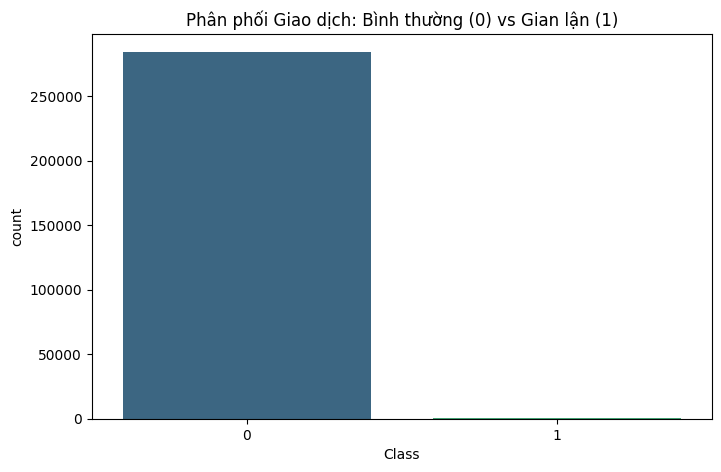


--- Thống kê cột Amount ---
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Phân phối Giao dịch: Bình thường (0) vs Gian lận (1)')
plt.show()

# 4. Phân tích cột Amount (Số tiền)
print("\n--- Thống kê cột Amount ---")
print(df['Amount'].describe())


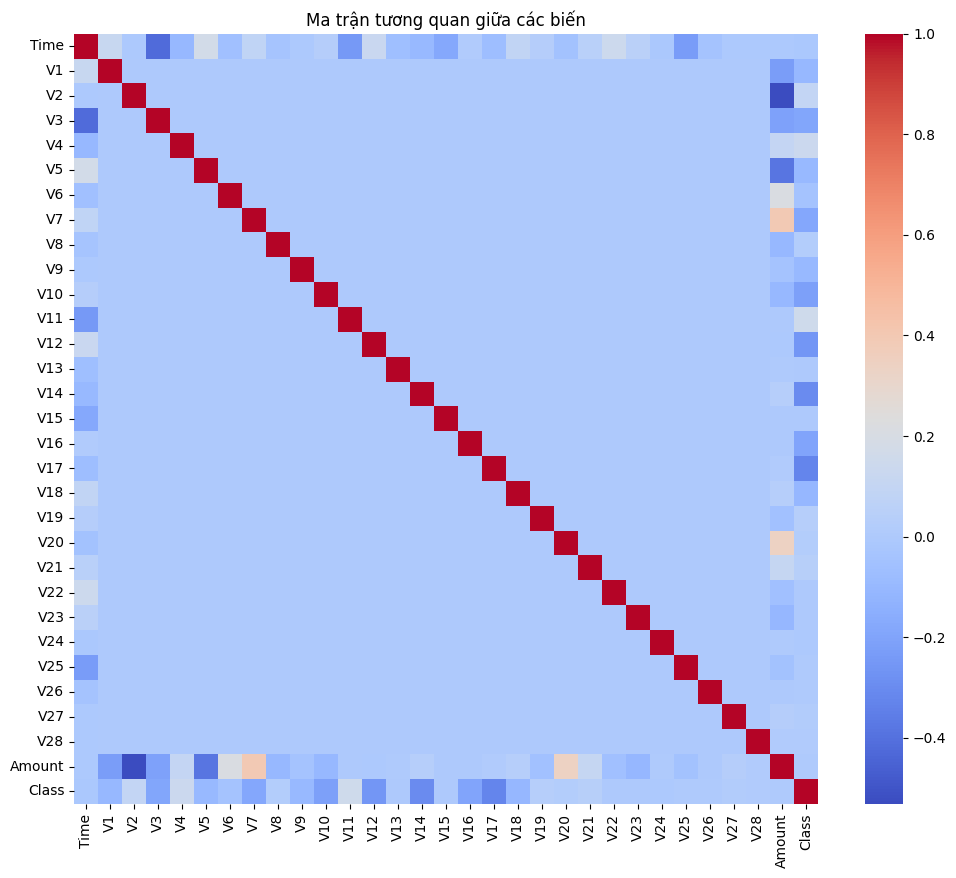

In [ ]:
# 5. Kiểm tra tương quan (Correlation Heatmap)
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Ma trận tương quan giữa các biến')
plt.show()

1. Tương quan giữa các biến V và Class
Nhìn vào hàng Class ở dưới cùng, bạn sẽ thấy các ô màu xanh đậm và nhạt khác nhau:

  Tương quan nghịch mạnh (Màu xanh đậm): Các biến như V17, V14, V12, V10 có màu xanh khá đậm. Điều này có nghĩa là khi giá trị của các biến này giảm xuống, xác suất giao dịch đó là gian lận (Class = 1) sẽ tăng lên. Đây thường là những tín hiệu mạnh nhất để mô hình nhận diện kẻ gian.

  Tương quan thuận (Màu hồng/cam nhạt): Một số biến như V4, V11 có xu hướng màu ấm hơn. Khi giá trị các biến này tăng, khả năng gian lận cũng tăng theo.

2. Biến Time và Amount
Time: Có tương quan rất yếu với Class. Điều này hợp lý vì gian lận có thể xảy ra ở bất cứ thời điểm nào, tuy nhiên nó có thể có quy luật theo chu kỳ (mà ma trận tương quan tuyến tính này chưa thể hiện hết).

Amount: Có tương quan nhẹ. Như chúng ta đã phân tích ở biểu đồ Boxplot trước, giá trị giao dịch gian lận thường nhỏ hơn so với các giao dịch hợp pháp cực lớn.

Từ kết quả EDA này (Boxplot và Heatmap), chúng ta đã xác định được:Dữ liệu bị mất cân bằng nghiêm trọng (cần xử lý ở bước sau).Amount và Time cần được Scaling (nên dùng RobustScaler).Có một số biến $V$ mang tín hiệu rất mạnh cho việc dự đoán.

Ở Bước 2: Tiền xử lý dữ liệu (Preprocessing), mục tiêu của chúng ta là đưa tất cả các đặc trưng về cùng một quy mô (scale) để các thuật toán như KNN hay Naive Bayes không bị "lệch" bởi những con số quá lớn.

Các công việc trong Bước 2:
1. Scaling: Chuẩn hóa hai cột Amount và Time.
2. Tách dữ liệu (Feature & Label): Chia dữ liệu thành biến độc lập ($X$) và biến mục tiêu ($y$).
3. Chia tập Train/Test: Tách theo tỷ lệ 80/20. Chúng ta dùng stratify=y để đảm bảo tỷ lệ gian lận ở cả hai tập là bằng nhau.

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

# Chuẩn hóa Amount và Time bằng RobustScaler (hiệu quả với Outliers)
rob_scaler = RobustScaler()
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time', 'Amount'], axis=1, inplace=True)
# Đẩy các cột đã scale lên đầu
cols = ['scaled_amount', 'scaled_time'] + [c for c in df.columns if c not in ['scaled_amount', 'scaled_time']]
df = df[cols]

display(df.head())

,scaled_amount,scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,1.783274,-0.994983,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.269825,-0.994983,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,4.983721,-0.994972,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.418291,-0.994972,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,0.670579,-0.994960,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


In [ ]:
# 3. Tách X (features) và y (target)
X = df.drop('Class', axis=1)
y = df['Class']

# 4. Chia tập Train và Test (80% Train, 20% Test)
# Quan trọng: stratify=y giúp giữ nguyên tỷ lệ 0.17% gian lận ở cả 2 tập
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n--- Kích thước các tập dữ liệu ---")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"Tỷ lệ gian lận trong tập Train: {y_train.value_counts(normalize=True)[1]:.4%}")


--- Kích thước các tập dữ liệu ---
X_train: (227845, 30)
X_test: (56962, 30)
Tỷ lệ gian lận trong tập Train: 0.1729%


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Khởi tạo SMOTE
# k_neighbors=5 là giá trị mặc định để tìm các điểm lân cận và tạo mẫu mới
sm = SMOTE(random_state=42)

# 2. Thực hiện lấy mẫu lại (Resampling) trên tập Train
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# 3. Kiểm tra kết quả sau khi cân bằng
print("--- Trước khi dùng SMOTE ---")
print(Counter(y_train))

print("\n--- Sau khi dùng SMOTE ---")
print(Counter(y_train_res))

--- Trước khi dùng SMOTE ---
Counter({0: 227451, 1: 394})

--- Sau khi dùng SMOTE ---
Counter({0: 227451, 1: 227451})


/tmp/ipykernel_861/1901751209.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_res, palette='magma')


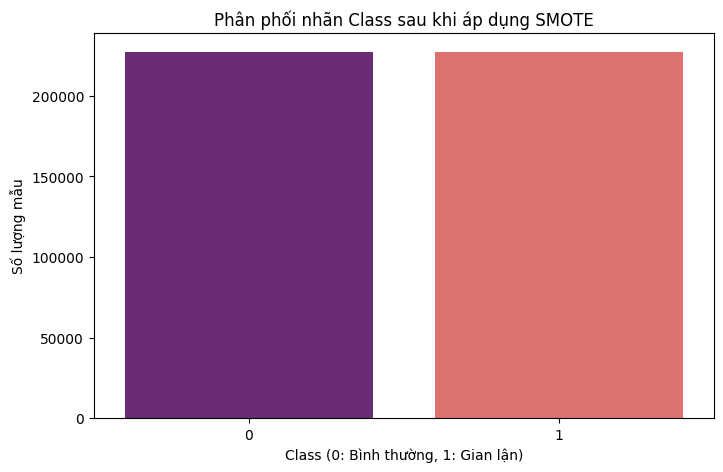

In [ ]:
# Trực quan hóa kết quả cân bằng
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_res, palette='magma')
plt.title('Phân phối nhãn Class sau khi áp dụng SMOTE')
plt.xlabel('Class (0: Bình thường, 1: Gian lận)')
plt.ylabel('Số lượng mẫu')
plt.show()

1. Phân tích & Thấu hiểu Dữ liệu (EDA)

Xác định cấu trúc: Bộ dữ liệu gồm 30 đặc trưng (Time, Amount và 28 biến ẩn V1-V28).

Phát hiện vấn đề cốt lõi: Dữ liệu bị mất cân bằng nghiêm trọng (chỉ có $0.17\%$ là gian lận).

Đặc điểm giao dịch: Qua biểu đồ Boxplot, chúng ta thấy giao dịch gian lận thường có giá trị nhỏ hoặc trung bình, trong khi các giao dịch cực lớn thường là hợp pháp.

Mối tương quan: Các biến $V17, V14, V12$ có tương quan nghịch mạnh nhất với hành vi gian lận.

2. Tiền xử lý dữ liệu (Preprocessing)

Scaling: Sử dụng RobustScaler để chuẩn hóa Amount và Time. Đây là lựa chọn thông minh vì bộ dữ liệu có nhiều điểm dị biệt (outliers).

Tách dữ liệu: Chia tập dữ liệu thành Train (80%) và Test (20%) có sử dụng stratify để giữ nguyên tỷ lệ nhãn gian lận ở cả hai phần.

3. Xử lý mất cân bằng(Oversampling)

Áp dụng SMOTE: Bạn đã huấn luyện thành công kỹ thuật SMOTE trên tập Train, đưa số lượng mẫu gian lận từ vài trăm lên ngang bằng với giao dịch bình thường (hơn 225,000 mẫu mỗi bên).

4. Khởi động huấn luyện (Baseline Models)

Thiết lập logic cho mô hình Naive Bayes và KNN.

Thống nhất hướng giải quyết cho người dùng cuối: Sử dụng giá trị trung bình (Mean) của các biến $V$ để giả lập đầu vào khi người dùng thực tế chỉ nhập Amount và Time.

Thư huấn luyện mô hình Naive Bayes để kiểm thử mô hình

In [ ]:
import numpy as np

class GaussianNB :
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.prior = {}

        for c in self.classes:
            # Chuyển DataFrame X_c sang NumPy array trước khi tính mean và var
            X_c_np = X[y == c].values
            self.mean[c] = np.mean(X_c_np, axis=0)
            self.var[c] = np.var(X_c_np, axis=0) + 1e-9  # tránh chia 0
            self.prior[c] = X_c_np.shape[0] / X.shape[0]

    def gaussian_log_prob(self, x, mean, var):
        # x ở đây đã là NumPy array nếu predict lặp qua X.values
        return -0.5 * np.log(2 * np.pi * var) - ((x - mean) ** 2) / (2 * var)

    def predict(self, X):
        y_pred = []
        # Chuyển DataFrame X sang NumPy array trước khi lặp qua các hàng
        X_np = X.values

        for x_row in X_np:
            posteriors = []      # Posterior là mảng lưu xác suất với từng class, của 1 giao dịch cụ thể

            for c in self.classes:
                log_prior = np.log(self.prior[c])         # Đây là xác suất Log(P(c))
                log_likelihood = np.sum(
                    self.gaussian_log_prob(x_row, self.mean[c], self.var[c])     # Đây là tổng cộng dồn xác suất
                )
                posterior = log_prior + log_likelihood
                posteriors.append(posterior)

            y_pred.append(self.classes[np.argmax(posteriors)])      # Hàm chọn ra xác suất class cao nhất

        return np.array(y_pred)

In [ ]:
nb_model = GaussianNB()
nb_model.fit(X_train_res,y_train_res)

In [ ]:
y_pred = nb_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_model(y_true, y_pred):
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [ ]:
print("--- Kết quả đánh giá mô hình Gaussian Naive Bayes ---")
evaluate_model(y_test, y_pred)

--- Kết quả đánh giá mô hình Gaussian Naive Bayes ---
Accuracy : 0.9731224324988589
Precision: 0.05358255451713396
Recall   : 0.8775510204081632
F1-score : 0.10099823840281856

Confusion Matrix:
[[55345  1519]
 [   12    86]]


1. Accuracy (Số lg dự đoán đúng trong tất cả dự đoán đưa ra) : Cao, nhưng do Dataset quá lệch về hướng 0, nên thông số này ko mang nhiều ý nghĩa
2. Precision : Thấp, ý nghĩa : trong số các Giao dịch dự đoán là Fraud, chỉ 5% thực sự là Fraud --> Thông báo nhầm Fraud rất nhiều.
3. Recall :  Cao , ý nghĩa :  Trong số giao dịch thật sự là Fraud thì đã phát hiện được khoảng 85% --> Phát hiện được đa số giao dịch Fraud
4. F1-score : Thấp , do Precision thấp nên F1 Score ko thể cao , ý nghĩa : Model tuy Bắt được đa số giao dịch Fraud , nhưng bắt nhầm rất nhiều.

* Giải thích nguyên nhân :
1. Database Test quá Imbalanced
2. Giả định Gaussian Naive Bayes chưa chuẩn : Các Features cần độc lập với nhau, và trong 1 class thì mỗi Feature phải phân phối chuẩn
3. Navie Bayes quá đơn giản, nó giống như Rule-Based thống kê, chứ ko có yếu tố "Learning" đúng nghĩa : Ko có Gradient Decent, Tối ưu hàm Loss
 NB học 2 tham số là Mean và SD, trong khi Data thực tế rất phức tạp : Có nhiều đỉnh , lệch (Skewed), nhiều outlier

 Vdu : Mô hình gốc cho thấy những giao dịch cực lớn thường là Real, nhưng với mô hình này, nó hoàn toàn ko học được điều này

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

rng = np.random.RandomState(42)

X_train_res_np = X_train_res.to_numpy() if hasattr(X_train_res, "to_numpy") else np.asarray(X_train_res)
y_train_res_np = y_train_res.to_numpy() if hasattr(y_train_res, "to_numpy") else np.asarray(y_train_res)
X_test_np = X_test.to_numpy() if hasattr(X_test, "to_numpy") else np.asarray(X_test)
y_test_np = y_test.to_numpy() if hasattr(y_test, "to_numpy") else np.asarray(y_test)

idx_train_0 = np.where(y_train_res_np == 0)[0]
idx_train_1 = np.where(y_train_res_np == 1)[0]

train_0 = rng.choice(idx_train_0, 3000, replace=False)
train_1 = rng.choice(idx_train_1, 3000, replace=False)
train_idx = np.concatenate([train_0, train_1])
rng.shuffle(train_idx)

idx_test_0 = np.where(y_test_np == 0)[0]
idx_test_1 = np.where(y_test_np == 1)[0]

test_0 = rng.choice(idx_test_0, 2000, replace=False)
test_idx = np.concatenate([test_0, idx_test_1])
rng.shuffle(test_idx)

X_train_knn = X_train_res_np[train_idx]
y_train_knn = y_train_res_np[train_idx]
X_test_knn = X_test_np[test_idx]
y_test_knn = y_test_np[test_idx]

print("Train shape:", X_train_knn.shape)
print("Test shape:", X_test_knn.shape)
print(pd.Series(y_train_knn).value_counts())
print(pd.Series(y_test_knn).value_counts())

Train shape: (6000, 30)
Test shape: (2098, 30)
1    3000
0    3000
Name: count, dtype: int64
0    2000
1      98
Name: count, dtype: int64


In [ ]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

def knn_predict_one(X_train, y_train, x, k):
    distances = np.array([euclidean_distance(x, x_train) for x_train in X_train])
    nearest_idx = np.argsort(distances)[:k]
    nearest_labels = y_train[nearest_idx]
    values, counts = np.unique(nearest_labels, return_counts=True)
    return values[np.argmax(counts)]

def knn_predict(X_train, y_train, X_test, k):
    predictions = []
    for x in X_test:
        predictions.append(knn_predict_one(X_train, y_train, x, k))
    return np.array(predictions)

In [ ]:
for k in [3, 5, 7, 9, 11]:
    y_pred = knn_predict(X_train_knn, y_train_knn, X_test_knn, k)

    print(f"\n===== K = {k} =====")
    print("Accuracy:", accuracy_score(y_test_knn, y_pred))
    print("Precision:", precision_score(y_test_knn, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test_knn, y_pred, zero_division=0))
    print("F1-score:", f1_score(y_test_knn, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test_knn, y_pred))


===== K = 3 =====
Accuracy: 0.9623450905624404
Precision: 0.5590062111801242
Recall: 0.9183673469387755
F1-score: 0.694980694980695
Confusion Matrix:
[[1929   71]
 [   8   90]]

===== K = 5 =====
Accuracy: 0.9590085795996187
Precision: 0.5352941176470588
Recall: 0.9285714285714286
F1-score: 0.6791044776119403
Confusion Matrix:
[[1921   79]
 [   7   91]]

===== K = 7 =====
Accuracy: 0.953765490943756
Precision: 0.5027624309392266
Recall: 0.9285714285714286
F1-score: 0.6523297491039427
Confusion Matrix:
[[1910   90]
 [   7   91]]

===== K = 9 =====
Accuracy: 0.9532888465204957
Precision: 0.5
Recall: 0.9183673469387755
F1-score: 0.6474820143884892
Confusion Matrix:
[[1910   90]
 [   8   90]]

===== K = 11 =====
Accuracy: 0.9523355576739753
Precision: 0.4945054945054945
Recall: 0.9183673469387755
F1-score: 0.6428571428571429
Confusion Matrix:
[[1908   92]
 [   8   90]]


In [ ]:
k_best = 3
y_pred_best = knn_predict(X_train_knn, y_train_knn, X_test_knn, k_best)

print("K tốt nhất:", k_best)
print("Accuracy:", accuracy_score(y_test_knn, y_pred_best))
print("Precision:", precision_score(y_test_knn, y_pred_best, zero_division=0))
print("Recall:", recall_score(y_test_knn, y_pred_best, zero_division=0))
print("F1-score:", f1_score(y_test_knn, y_pred_best, zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_knn, y_pred_best))
print("\nClassification Report:")
print(classification_report(y_test_knn, y_pred_best, zero_division=0))

K tốt nhất: 3
Accuracy: 0.9623450905624404
Precision: 0.5590062111801242
Recall: 0.9183673469387755
F1-score: 0.694980694980695

Confusion Matrix:
[[1929   71]
 [   8   90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      2000
           1       0.56      0.92      0.69        98

    accuracy                           0.96      2098
   macro avg       0.78      0.94      0.84      2098
weighted avg       0.98      0.96      0.97      2098



### Lưu ý về KNN tự xây dựng
Thuật toán KNN tự cài đặt được thực hiện trên một tập con (6000 mẫu train, 2098 mẫu test) để minh họa logic tính toán khoảng cách Euclid mà không làm quá tải tài nguyên hệ thống, trong khi vẫn đảm bảo tính đại diện cho cả hai lớp.

Nhận xét kết quả KNN tự build:

Với K = 3, mô hình KNN tự build đạt Accuracy khoảng 96.23%, Precision khoảng 56.00%, Recall khoảng 91.84% và F1-score khoảng 69.50%. Kết quả này cho thấy mô hình phát hiện được phần lớn giao dịch gian lận, vì recall của lớp gian lận đạt mức khá cao. Cụ thể, trong 98 giao dịch gian lận ở tập test, mô hình phát hiện đúng 90 giao dịch và chỉ bỏ sót 8 giao dịch.

Tuy nhiên, mô hình vẫn còn dự đoán nhầm một số giao dịch bình thường thành gian lận, thể hiện qua precision chưa quá cao. Điều này là dễ hiểu trong bài toán fraud detection, vì mô hình được thiết kế theo hướng ưu tiên phát hiện gian lận hơn là giảm tối đa cảnh báo nhầm.

Nhìn chung, phần KNN tự build đã mô phỏng đúng logic của thuật toán KNN: tính khoảng cách Euclid giữa điểm test và các điểm train, chọn K láng giềng gần nhất, sau đó dự đoán theo nhãn xuất hiện nhiều nhất. Kết quả thu được tương đối tốt và cho thấy thuật toán tự cài đặt hoạt động đúng.

KNN tự build:

Ở phần này, nhóm tự cài đặt lại thuật toán KNN thay vì sử dụng trực tiếp thư viện có sẵn. Mục tiêu là để hiểu rõ bản chất hoạt động của KNN, bao gồm các bước: tính khoảng cách giữa điểm cần dự đoán với các điểm trong tập train, chọn K láng giềng gần nhất, sau đó dự đoán nhãn theo nguyên tắc bỏ phiếu đa số.

Do bộ dữ liệu sau khi áp dụng SMOTE có kích thước rất lớn, nếu chạy KNN tự cài đặt trên toàn bộ tập train và test thì thời gian tính toán sẽ rất lâu, dễ vượt quá khả năng xử lý của Colab. Vì vậy, nhóm chọn một tập con đại diện để kiểm chứng thuật toán. Cụ thể, ở tập train nhóm lấy 3000 mẫu lớp 0 và 3000 mẫu lớp 1 để giữ dữ liệu cân bằng, còn ở tập test nhóm lấy 2000 mẫu lớp 0 và giữ toàn bộ 98 mẫu lớp 1 nhằm đảm bảo vẫn đánh giá được khả năng phát hiện gian lận của mô hình.

Trong phần tự build này, nhóm sử dụng khoảng cách Euclid vì đây là cách đo khoảng cách phổ biến và phù hợp với KNN khi dữ liệu đã được chuẩn hóa trước đó. Sau đó, nhóm thử các giá trị K = 3, 5, 7, 9, 11 để tìm ra giá trị K phù hợp nhất cho mô hình.

## Bước 5: Huấn luyện mô hình XGBoost và Random Forest

Trong phần này, chúng ta sẽ sử dụng hai thuật toán mạnh mẽ dựa trên Ensemble Learning là Random Forest và XGBoost. Do yêu cầu sử dụng mô hình tối ưu, chúng ta sẽ thiết lập các Hyperparameters phù hợp để xử lý dữ liệu sau khi SMOTE.

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

# ========== 2. Random Forest ==========
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# ========== 3. Evaluation ==========
def evaluate_model(y_true, y_pred, y_proba=None):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

    if y_proba is not None:
        print("ROC-AUC:", roc_auc_score(y_true, y_proba))

# ========== 4. Train Random Forest ==========
print("Đang huấn luyện Random Forest...")
rf_model.fit(X_train_res, y_train_res)

print("Hoàn tất huấn luyện Random Forest!")

# ========== 5. Predict Random Forest ==========
y_pred_rf = rf_model.predict(X_test)

# ========== 6. Evaluate Random Forest ==========
print("\n--- Random Forest ---")
evaluate_model(y_test, y_pred_rf)


Đang huấn luyện Random Forest...
Hoàn tất huấn luyện Random Forest!

--- Random Forest ---
Accuracy: 0.9994908886626171
Confusion Matrix:
 [[56851    13]
 [   16    82]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
from xgboost import XGBClassifier

# Tính tỷ lệ cân bằng
ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model_combined = XGBClassifier(
    n_estimators=300,
    learning_rate=0.02,    # Học chậm lại vì đặc trưng văn bản rất dễ gây overfitting
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7,
    scale_pos_weight=ratio,
    gamma=2,               # Phạt nặng các cây phức tạp
    random_state=42,
    eval_metric='logloss'
)
# Với XGBoost, bạn có thể huấn luyện trên X_train gốc (chưa SMOTE) vì đã có scale_pos_weight
xgb_model_combined.fit(X_train, y_train)

# 4. Dự đoán
y_pred = xgb_model_combined.predict(X_test)
y_probs = xgb_model_combined.predict_proba(X_test)[:, 1]

# 5. Đánh giá
print("\n--- KẾT QUẢ XGBOOST (TABULAR ONLY) ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")


--- KẾT QUẢ XGBOOST (TABULAR ONLY) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.50      0.87      0.63        98

    accuracy                           1.00     56962
   macro avg       0.75      0.93      0.82     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9796


Với bài toán Fraud Detection: Bạn dùng Embedding để biến các mô tả giao dịch thành vector, sau đó mới đưa vào XGBoost hay Random Forest để phân loại.

với dữ liệu dạng bảng có cả các word thì dùng lstm

Tại Backend: Bạn viết một hàm dịch (Translate API) hoặc dùng một bộ từ điển Keyword để chuyển các từ khóa tiếng Việt nhạy cảm sang tiếng Anh tương ứng.

Tại Model: giải thích trong báo cáo rằng: "Chúng tôi sử dụng một module tiền xử lý ngôn ngữ để chuẩn hóa nội dung tiếng Việt về không gian đặc trưng chung (Common Feature Space) trước khi đưa vào mô hình đã được tiền huấn luyện trên dữ liệu quốc tế."

drop bớt các cột ko ảnh hưởng nhiều đến kết quả đầu ra như các vột $V22, V23, V25, V26$

Các cột nên loại bỏ ngay: $V22, V23, V25, V26, V27, V28, V8, V13, V15, V24$.

In [ ]:
import pandas as pd
import random
import numpy as np

random.seed(42)
np.random.seed(42)

safe_templates = [
    "chuyen {amount}k cho {person}", "thanh toan {service} {amount}k", "nhan luong thang {month}",
    "chuyen tien an uong {amount}k", "gui {person} {amount}k", "tra tien {service}",
    "chuyen tien sinh hoat", "nop hoc phi {amount}k", "thanh toan hoa don",
    "gui tang qua sinh nhat {person}", "thanh toan tien di cho {amount}k", "chuyen khoan mua do an sang",
    "tra no tien cafe hom qua", "chuyen tien phong thang {month}", "thanh toan cuoc phi dien thoai",
    "gui tien mung dam cuoi", "thanh toan don hang shopee {amount}k", "chuyen tien mua quan ao",
    "thanh toan grab {amount}k", "gui tien tiet kiem cho {person}", "chuyen tien tap gym",
    "tra tien mua sach", "thanh toan ve xem phim", "chuyen tien di du lich",
    "thanh toan cuoc internet thang {month}", "mua do gia dung {amount}k", "chuyen tien xang xe",
    "thanh toan tiki {amount}k", "tra tien di cho cho {person}", "nap tien dien thoai {amount}k",
    "chuyen tien mung thoi noi", "thanh toan bao hiem suc khoe", "mua ve may bay di du lich",
    "thanh toan tra gop dien thoai", "chuyen tien mung tan gia", "mua hoa tang {person}",
    "thanh toan spotify", "chuyen khoan dat coc phong", "tra tien an toi cung {person}",
    "thanh toan grabfood {amount}k", "chuyen tien sua xe", "mua linh kien may tinh",
    "thanh toan hoa don nuoc {month}", "gui tien tieu vat cho {person}", "chuyen tien mua thuoc",
    "thanh toan phi bao tri chung cu", "mua do trang tri nha cua", "chuyen tien hoc them cho {person}",
    "thanh toan cuoc truyen hinh", "mua qua tet cho gia dinh", "chuyen khoan mua laptop",
    "thanh toan phi do xe {month}", "mua my pham tang {person}", "tra tien vay tieu dung",
    "chuyen khoan thanh toan lazada", "mua tivi moi cho {person}", "thanh toan hoa don k+",
    "gui tien mung tho bac", "chuyen tien lam rang su", "mua dong ho thong minh"
]

fraud_templates = [
    "chuyen tien gap {amount}k ngay", "xac nhan trung thuong {amount} trieu", "tai khoan bi khoa chuyen {amount}k",
    "gui tien xac minh tai khoan {amount}k", "co viec gap can {amount}k", "nap tien ngay de nhan thuong",
    "tai khoan bi loi can chuyen tien", "chuyen tien de mo khoa tai khoan", "canh báo bao mat tai khoan chuyen {amount}k xac nhan",
    "ban co mot don hang chua thanh toan {amount}k", "nhan qua mien phi bam vao link ngay",
    "yeu cau xac thuc danh tinh de rut {amount} trieu", "nop phat vi vi phat giao thong {amount}k",
    "co quan chuc nang yeu cau kiem tra tai khoan", "chuyen tien vao tai khoan tam giu de dieu tra",
    "ung dung dang bi hack chuyen ngay {amount}k", "tro giup khan cap cho {person} dang gap nan",
    "nhan uu dai khung khi nap {amount}k vao game", "yeu cau thanh toan no qua han neu khong se bi kien",
    "tang qua tri an khach hang bam vao lien ket", "canh bao dang nhap la tu thiet bi khac",
    "nhan ho tro tu chinh phu {amount} trieu", "tai khoan ngan hang tam khoa do nghi van gian lau",
    "yeu cau cung cap ma OTP de tiep tuc giao dich", "lam nhiem vu online kiem {amount}k moi ngay",
    "vay von tin dung lai suat 0 phan tram", "thong bao trung thuong xe may SH",
    "nhan vien ngan hang ho tro lay lai mat khau", "bam vao day de nhan tien hoan thue",
    "yeu cau cap nhat thong tin cccd ngay", "don hang bi thieu can thanh toan bo sung {amount}k",
    "moi hop tac kinh doanh loi nhuan cao", "nhan ma giam gia 50 phan tram tai day",
    "xac nhan so du tai khoan tang dot bien", "yeu cau rut tien ve vi dien tu lien ket",
    "thong bao co kien hang bi tam giu tai hai quan", "cung cap thong tin ngan hang de nhan luong ho tro",
    "tai khoan icloud bi xam nhap bam vao link", "dang ky nhan goi qua tet 0 dong",
    "xac nhan khoan vay tin dung {amount} trieu", "canh bao vi pham ban quyen tren facebook",
    "moi tham gia khao sat nhan tien mat", "xac nhan giao dich thanh cong {amount}k",
    "yeu cau doi mat khau ngay lap tuc", "he thong dang bao tri vui long dang nhap lai"
]

persons = ["me", "ban", "anh", "chi", "doi tac", "em", "bo", "dong nghiep", "thay co", "vo", "chong", "em ho", "bac", "co", "chu", "ong", "ba"]
services = ["tien dien", "tien nuoc", "internet", "hoc phi", "chung cu", "bao hiem", "netflix", "phong tap", "truyen hinh cap", "rac thai", "phi quan ly", "dien thoai", "xang xe"]
months = list(range(1, 13))

def generate_text(row):
    label = row['Class']
    raw_amount = row.get('Amount', random.randint(10000, 500000))
    amount = int(raw_amount / 1000)

    if label == 1:
        template = random.choice(fraud_templates)
    else:
        template = random.choice(safe_templates)

    return template.format(
        amount=amount,
        person=random.choice(persons),
        service=random.choice(services),
        month=random.choice(months)
    )

df['Transaction_Content'] = df.apply(generate_text, axis=1)
print(f"Da cap nhat Transaction_Content: {len(safe_templates)} mau an toan, {len(fraud_templates)} mau gian lan.")

Da cap nhat Transaction_Content: 60 mau an toan, 45 mau gian lan.


In [ ]:
# Xem 5 dòng đầu tiên
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V22       V23       V24       V25       V26  \
0  0.098698  0.363787  ...  0.277838 -0.110474  0.066928  0.128539 -0.189115   
1  0.085102 -0.255425  ... -0.638672  0.101288 -0.339846  0.167170  0.125895   
2  0.247676 -1.514654  ...  0.771679  0.909412 -0.689281 -0.327642 -0.139097   
3  0.377436 -1.387024  ...  0.005274 -0.190321 -1.175575  0.647376 -0.221929   
4 -0.270533  0.817739  ...  0.798278 -0.137458  0.141267 -0.206010  0.502292   

        V27       V28  Amount  C

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Lấy cột text
text_data = df['Transaction_Content']

# Khởi tạo TF-IDF
tfidf = TfidfVectorizer(
    max_features=3000,      # số lượng từ tối đa
    ngram_range=(1, 2),     # unigram + bigram
    min_df=2,               # bỏ từ xuất hiện < 2 lần
    max_df=0.95             # bỏ từ quá phổ biến
)

# Fit và transform
X_text = tfidf.fit_transform(text_data)

In [ ]:
print(X_text.shape)

(284807, 3000)


In [ ]:
print(tfidf.get_feature_names_out()[:20])

['10' '100k' '100k cho' '101k' '101k cho' '102k' '102k cho' '103k'
 '103k cho' '104k' '104k cho' '105k' '105k cho' '106k' '106k cho' '107k'
 '107k cho' '108k' '108k cho' '109k']


In [ ]:
print(X_text[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 6 stored elements and shape (1, 3000)>
  Coords	Values
  (0, 2479)	0.2307412237774732
  (0, 2494)	0.2307412237774732
  (0, 1693)	0.3587719052651559
  (0, 541)	0.7301893237025199
  (0, 2480)	0.2307412237774732
  (0, 2497)	0.42235261866394164


In [ ]:
import pandas as pd
from scipy.sparse import hstack

# Columns to drop as requested by the user
columns_to_drop = ['V22', 'V23', 'V25', 'V26', 'V27', 'V28', 'V8', 'V13', 'V15', 'V24']

# Create a copy of the DataFrame to avoid modifying the original 'df' if it's used elsewhere
df_processed = df.copy()

# Drop the specified columns
df_processed.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# Verify the remaining columns
print("Columns after dropping:", df_processed.columns.tolist())
display(df_processed.head())

tabular_cols = [col for col in df_processed.columns if col not in ['Class', 'Transaction_Content']]

X_tabular = df_processed[tabular_cols].values
y = df_processed['Class']

X = hstack([X_text, X_tabular])

Columns after dropping: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V9', 'V10', 'V11', 'V12', 'V14', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'Amount', 'Class', 'Transaction_Content']


,Time,V1,V2,V3,V4,V5,V6,V7,V9,V10,...,V14,V16,V17,V18,V19,V20,V21,Amount,Class,Transaction_Content
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.363787,0.090794,...,-0.311169,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,149.62,0,nop hoc phi 0k
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,-0.255425,-0.166974,...,-0.143772,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,2.69,0,thanh toan cuoc phi dien thoai
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,-1.514654,0.207643,...,-0.165946,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,378.66,0,chuyen tien hoc them cho anh
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,-1.387024,-0.054952,...,-0.287924,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,123.50,0,thanh toan hoc phi 0k
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,0.817739,0.753074,...,-1.119670,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,69.99,0,tra tien an toi cung me


In [ ]:
import joblib
import os

# Đảm bảo thư mục tồn tại trước khi lưu
os.makedirs('/content/models', exist_ok=True)

# 1. Save the list of tabular columns used for training
joblib.dump(tabular_cols, '/content/models/tabular_columns.joblib')

# 2. Calculate and save the mean of remaining V columns
v_cols_remaining = [col for col in tabular_cols if col.startswith('V')]
v_means = df_processed[v_cols_remaining].mean()

joblib.dump(v_means, '/content/models/v_feature_means.joblib')

print("Artifacts created successfully in /content/models/")
display(v_means)

Artifacts created successfully in /content/models/


,0
V1,1.168375e-15
V2,3.416908e-16
V3,-1.379537e-15
V4,2.074095e-15
V5,9.604066e-16
V6,1.487313e-15
V7,-5.556467e-16
V9,-2.406331e-15
V10,2.239053e-15
V11,1.673327e-15


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import joblib
import os
from xgboost import XGBClassifier

# 1. Chia dữ liệu trước để có y_train
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Tính tỷ lệ cân bằng dựa trên tập huấn luyện thực tế
# ratio = số mẫu âm / số mẫu dương
ratio = (y_train == 0).sum() / (y_train == 1).sum()

# 3. Khởi tạo mô hình với ratio vừa tính
xgb_model_combined = XGBClassifier(
    n_estimators=300,
    learning_rate=0.02,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.7,
    scale_pos_weight=ratio,
    gamma=2,
    random_state=42,
    eval_metric='logloss'
)

# 4. Huấn luyện
print(f"Đang huấn luyện XGBoost với ratio={ratio:.2f}...")
xgb_model_combined.fit(X_train, y_train)

# 5. Lưu mô hình và công cụ tiền xử lý
os.makedirs('/content/models', exist_ok=True)
joblib.dump(xgb_model_combined, '/content/models/xgb_fraud_model_combined.joblib')
joblib.dump(tfidf, '/content/models/tfidf_vectorizer.joblib')
joblib.dump(rob_scaler, '/content/models/robust_scaler.joblib')
print("Đã lưu mô hình thành công!")

# 6. Dự đoán và đánh giá
y_pred = xgb_model_combined.predict(X_test)
y_probs = xgb_model_combined.predict_proba(X_test)[:, 1]

print("\n--- KẾT QUẢ XGBOOST (COMBINED DATA) ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

Đang huấn luyện XGBoost với ratio=577.29...
Đã lưu mô hình thành công!

--- KẾT QUẢ XGBOOST (COMBINED DATA) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.98      0.99      0.98        98

    accuracy                           1.00     56962
   macro avg       0.99      0.99      0.99     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 1.0000


### Pipeline: PhoBERT Feature Extraction + XGBoost (Full Dataset)
1. **PhoBERT**: Trích xuất 768 features từ `Transaction_Content`.
2. **Concatenation**: Ghép 768 features này với các cột số học (V1-V21, Amount, Time).
3. **XGBoost**: Huấn luyện bộ phân loại trên toàn bộ dữ liệu.

In [ ]:
import torch
from transformers import AutoModel, AutoTokenizer
import numpy as np
from tqdm import tqdm
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import joblib
import os
import gc

# 1. Cấu hình thiết bị
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang sử dụng: {device}")

# 2. Khởi tạo PhoBERT
phobert = AutoModel.from_pretrained("vinai/phobert-base").to(device)
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
phobert.eval()

def extract_phobert_features(texts, batch_size=64):
    all_embeddings = []
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Extracting Features"):
            batch_texts = texts[i:i+batch_size]
            inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=64).to(device)
            outputs = phobert(**inputs)
            # Chuyển sang float32 ngay lập tức để tiết kiệm RAM
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy().astype('float32')
            all_embeddings.append(cls_emb)
    return np.vstack(all_embeddings)

# 3. Trích xuất đặc trưng
print("Bước 1: Trích xuất đặc trưng PhoBERT...")
text_features_raw = extract_phobert_features(df['Transaction_Content'].tolist())

# 4. Giảm chiều bằng PCA
print("Bước 2: Giảm chiều PhoBERT xuống 128...")
pca = PCA(n_components=128, random_state=42)
text_features_reduced = pca.fit_transform(text_features_raw).astype('float32')

# GIẢI PHÓNG RAM QUAN TRỌNG
del text_features_raw
gc.collect()

# 5. Ghép với dữ liệu bảng
tabular_cols = [col for col in df.columns if col not in ['Class', 'Transaction_Content']]
X_tabular_full = df[tabular_cols].values.astype('float32')

X_final_full = np.hstack([X_tabular_full, text_features_reduced])
y_final_full = df['Class'].values
print(f"Cấu trúc siêu vector: {X_final_full.shape}")

# TIẾP TỤC GIẢI PHÓNG RAM
del X_tabular_full
del text_features_reduced
gc.collect()

# 6. Chia tập Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X_final_full, y_final_full, test_size=0.2, stratify=y_final_full, random_state=42
)

# 7. Huấn luyện XGBoost (Cấu hình tối ưu bộ nhớ)
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model_combined = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss',
    tree_method='gpu_hist' if device == 'cuda' else 'hist' # Dùng hist để giảm tải RAM
)

print(f"Bước 3: Huấn luyện XGBoost (Ratio: {ratio:.2f})...")
xgb_model_combined.fit(X_train, y_train)

# 8. Đánh giá
y_pred = xgb_model_combined.predict(X_test)
print("\n--- KẾT QUẢ PIPELINE (PHOBERT + XGBOOST) ---")
print(classification_report(y_test, y_pred))

os.makedirs('/content/models/pipeline_v3', exist_ok=True)
joblib.dump(xgb_model_combined, '/content/models/pipeline_v3/xgb_model.joblib')
joblib.dump(pca, '/content/models/pipeline_v3/pca_reducer.joblib')
print("Đã lưu model thành công.")

Đang sử dụng: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.decoder.weight          | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Bước 1: Trích xuất đặc trưng PhoBERT...


Extracting Features: 100%|██████████| 4451/4451 [03:45<00:00, 19.74it/s]


Bước 2: Giảm chiều PhoBERT xuống 128...
Cấu trúc siêu vector: (284807, 158)
Bước 3: Huấn luyện XGBoost (Ratio: 577.29)...


XGBoostError: Invalid Input: 'gpu_hist', valid values are: {'approx', 'auto', 'exact', 'hist'}